# Qiskit Introduction

Since the compute time on actual quantum computers is an expensive commodity,
we will for the most part in this course use
[$\texttt{qiskit\_aer}$](https://qiskit.github.io/qiskit-aer/getting_started.html)
to simulate quantum circuits.

Here we give the basic setup for using $\texttt{qiskit\_aer}$ as a backend in $\texttt{qiskit}$.
The advantages of this approach are
- The possibility of noisy simulations
- The deployment on actual quantum hardware only requiring a name change of the backend

For now we will use the default configuration of $\texttt{AerSimulator}$ which only produces shot noise from the finite number of measurements.

You can find further information under [Qiskit Runtime local testing mode](https://quantum.cloud.ibm.com/docs/en/guides/local-testing-mode).

$\texttt{qiskit\_aer}$ provides the simulation backend

$\texttt{qiskit\_ibm\_runtime}$ provides the sampler primitive

$\texttt{qiskit}$ provides all the basics for circuit building and transpilation


In [1]:
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import QuantumCircuit, generate_preset_pass_manager, QuantumRegister, ClassicalRegister
from qiskit.primitives import BitArray
from qiskit.visualization import plot_histogram

# 1 Basic setup

### 1.1 Build circuit

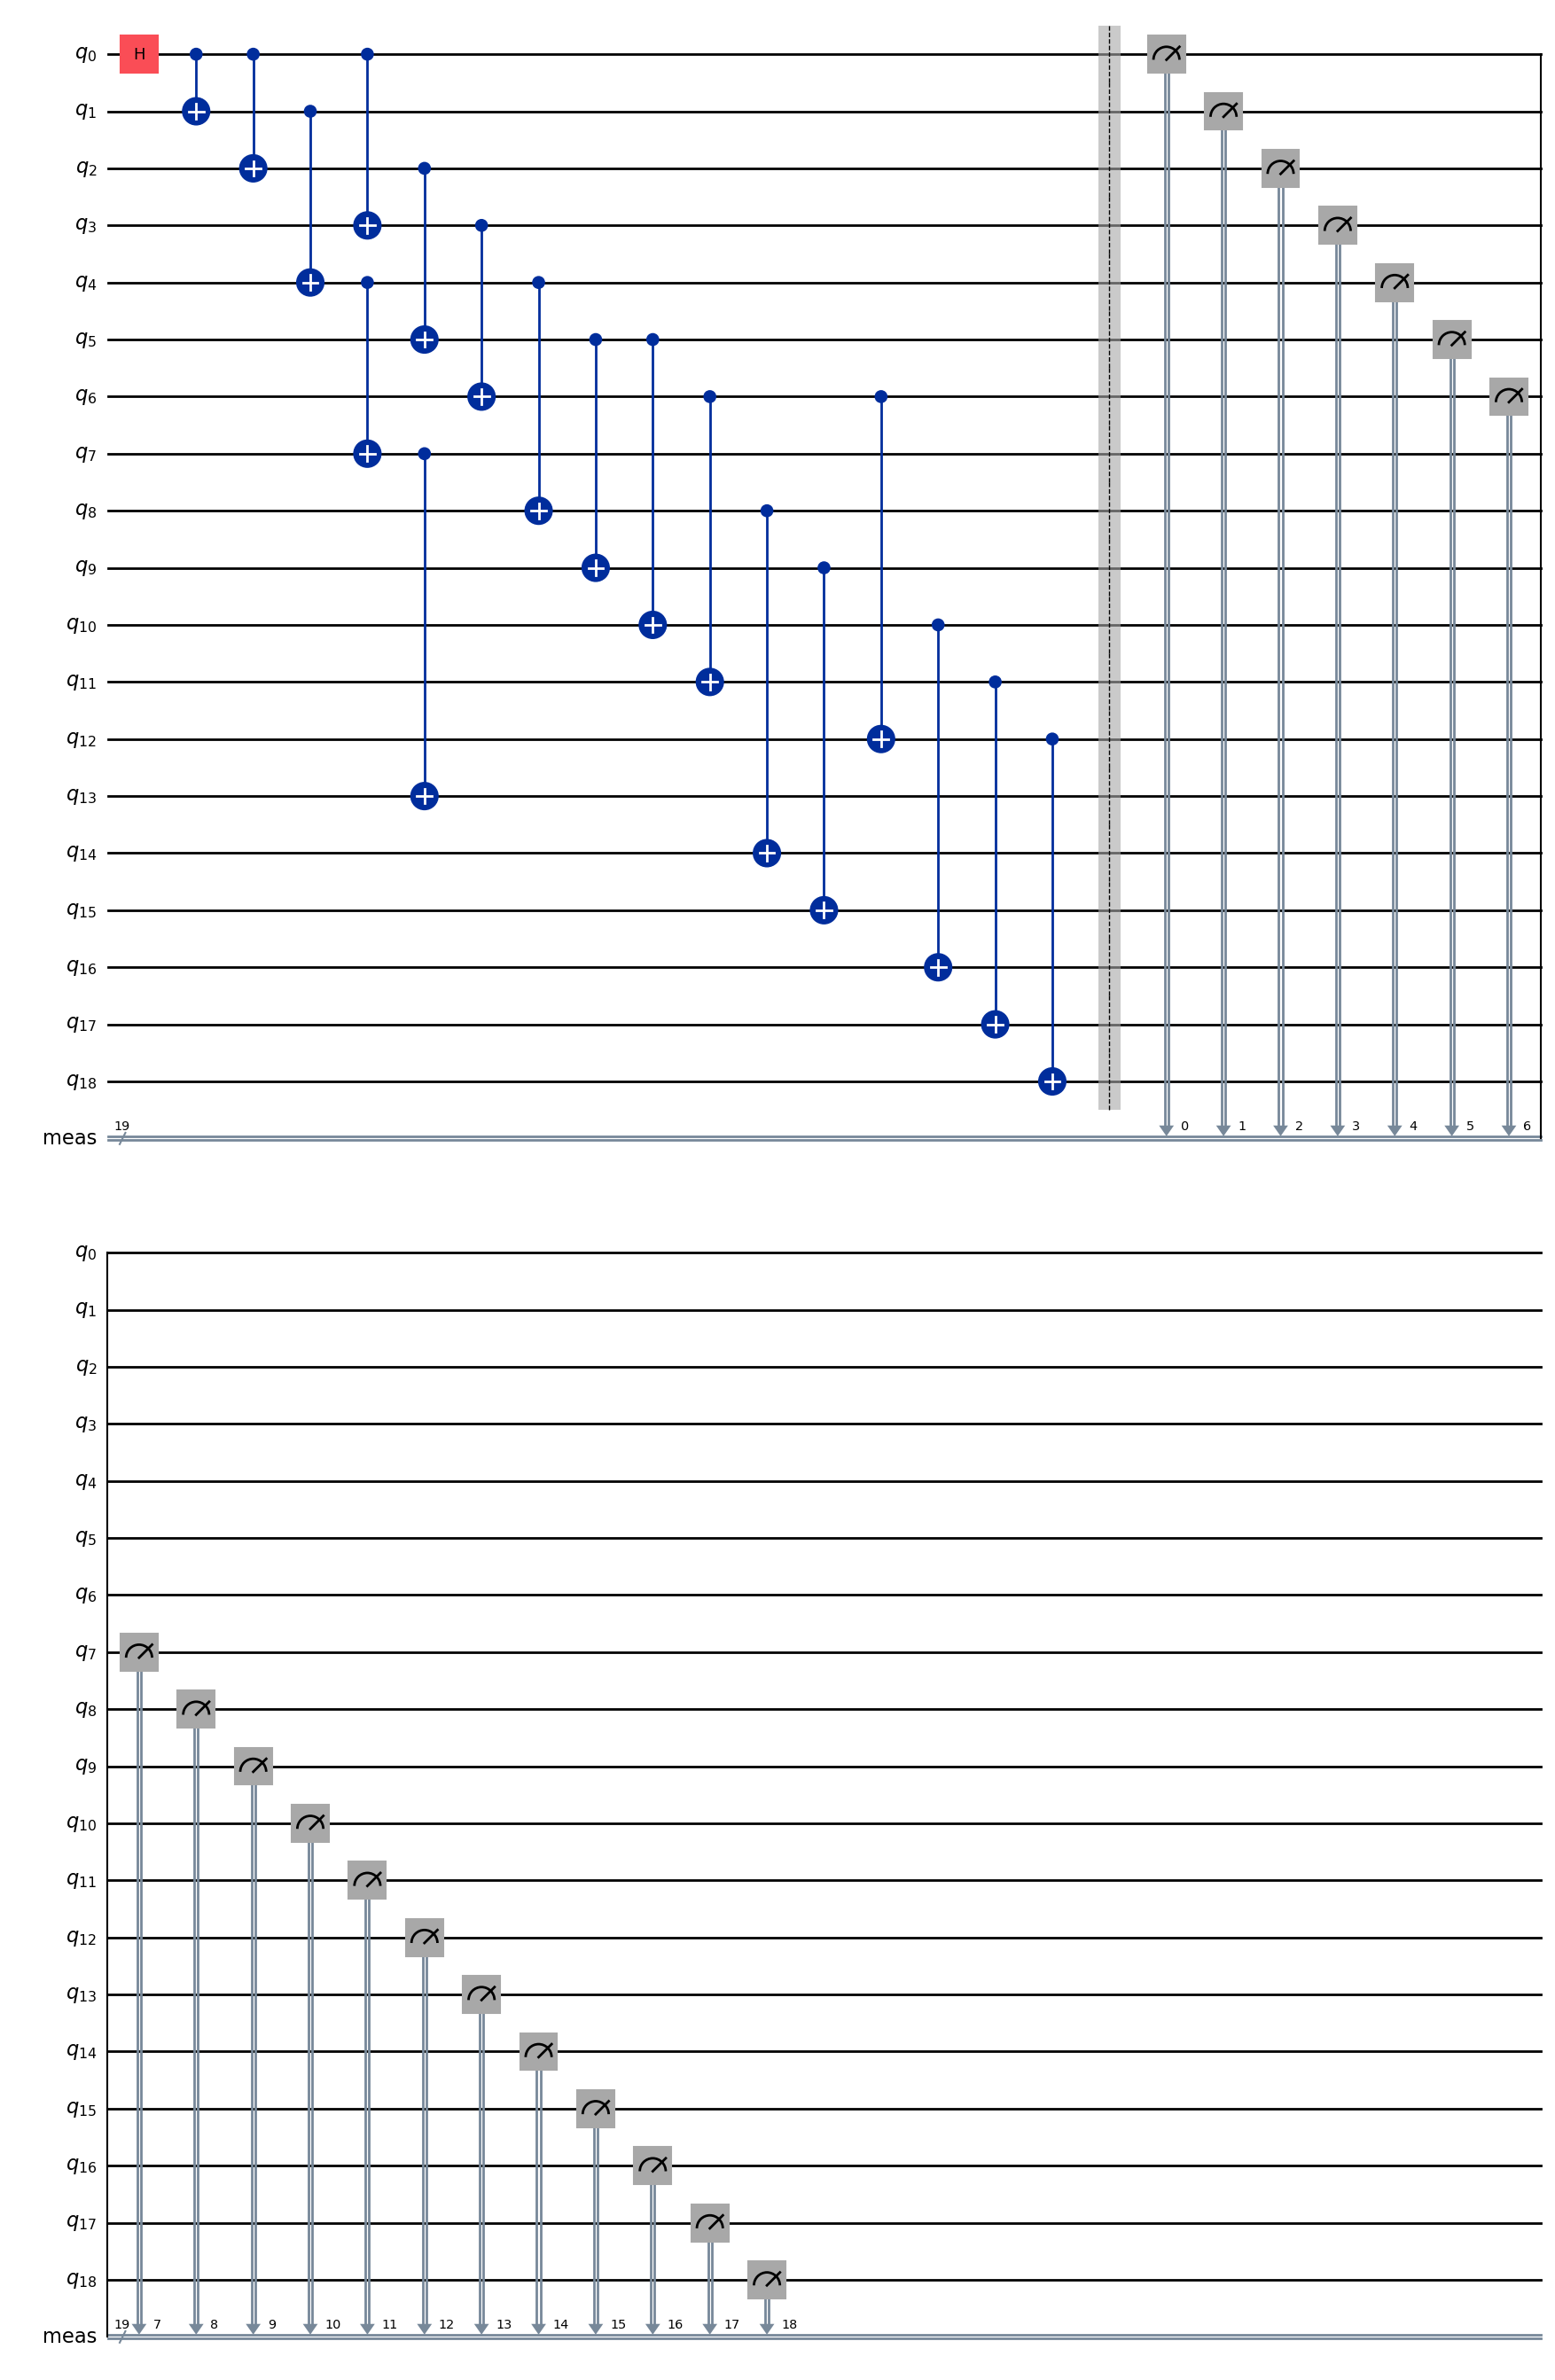

In [19]:
# In this case the only argument to QuantumCircuit is the number of Qubits
length = 19
qc = QuantumCircuit(length)

# Build a simple example circuit:
qc.h(0)
# for i in range(1, length):
#     qc.cx(0,i)
qc.cx(0, 1)
qc.cx(0, 2)
qc.cx(0, 3)

qc.cx(1, 4)
qc.cx(2, 5)
qc.cx(3, 6)

qc.cx(4, 7)
qc.cx(4, 8)
qc.cx(5, 9)
qc.cx(5, 10)
qc.cx(6, 11)
qc.cx(6, 12)

qc.cx(7, 13)
qc.cx(8, 14)
qc.cx(9, 15)
qc.cx(10, 16)
qc.cx(11, 17)
qc.cx(12, 18)


# This adds a ClassicalRegister to the QuantumCircuit
# and adds measurements for all Qubits into that ClassicalRegister.
qc.measure_all()

# Visualize the circuit:
qc.draw(output='mpl', filename='clever.pdf')

**Note** the name of the shown ClassicalRegister. By default, $\texttt{measure\_all}$ assigns the name **meas**.

See **Custom classical registers** below for an alternative.

### 1.2 Transpile circuit

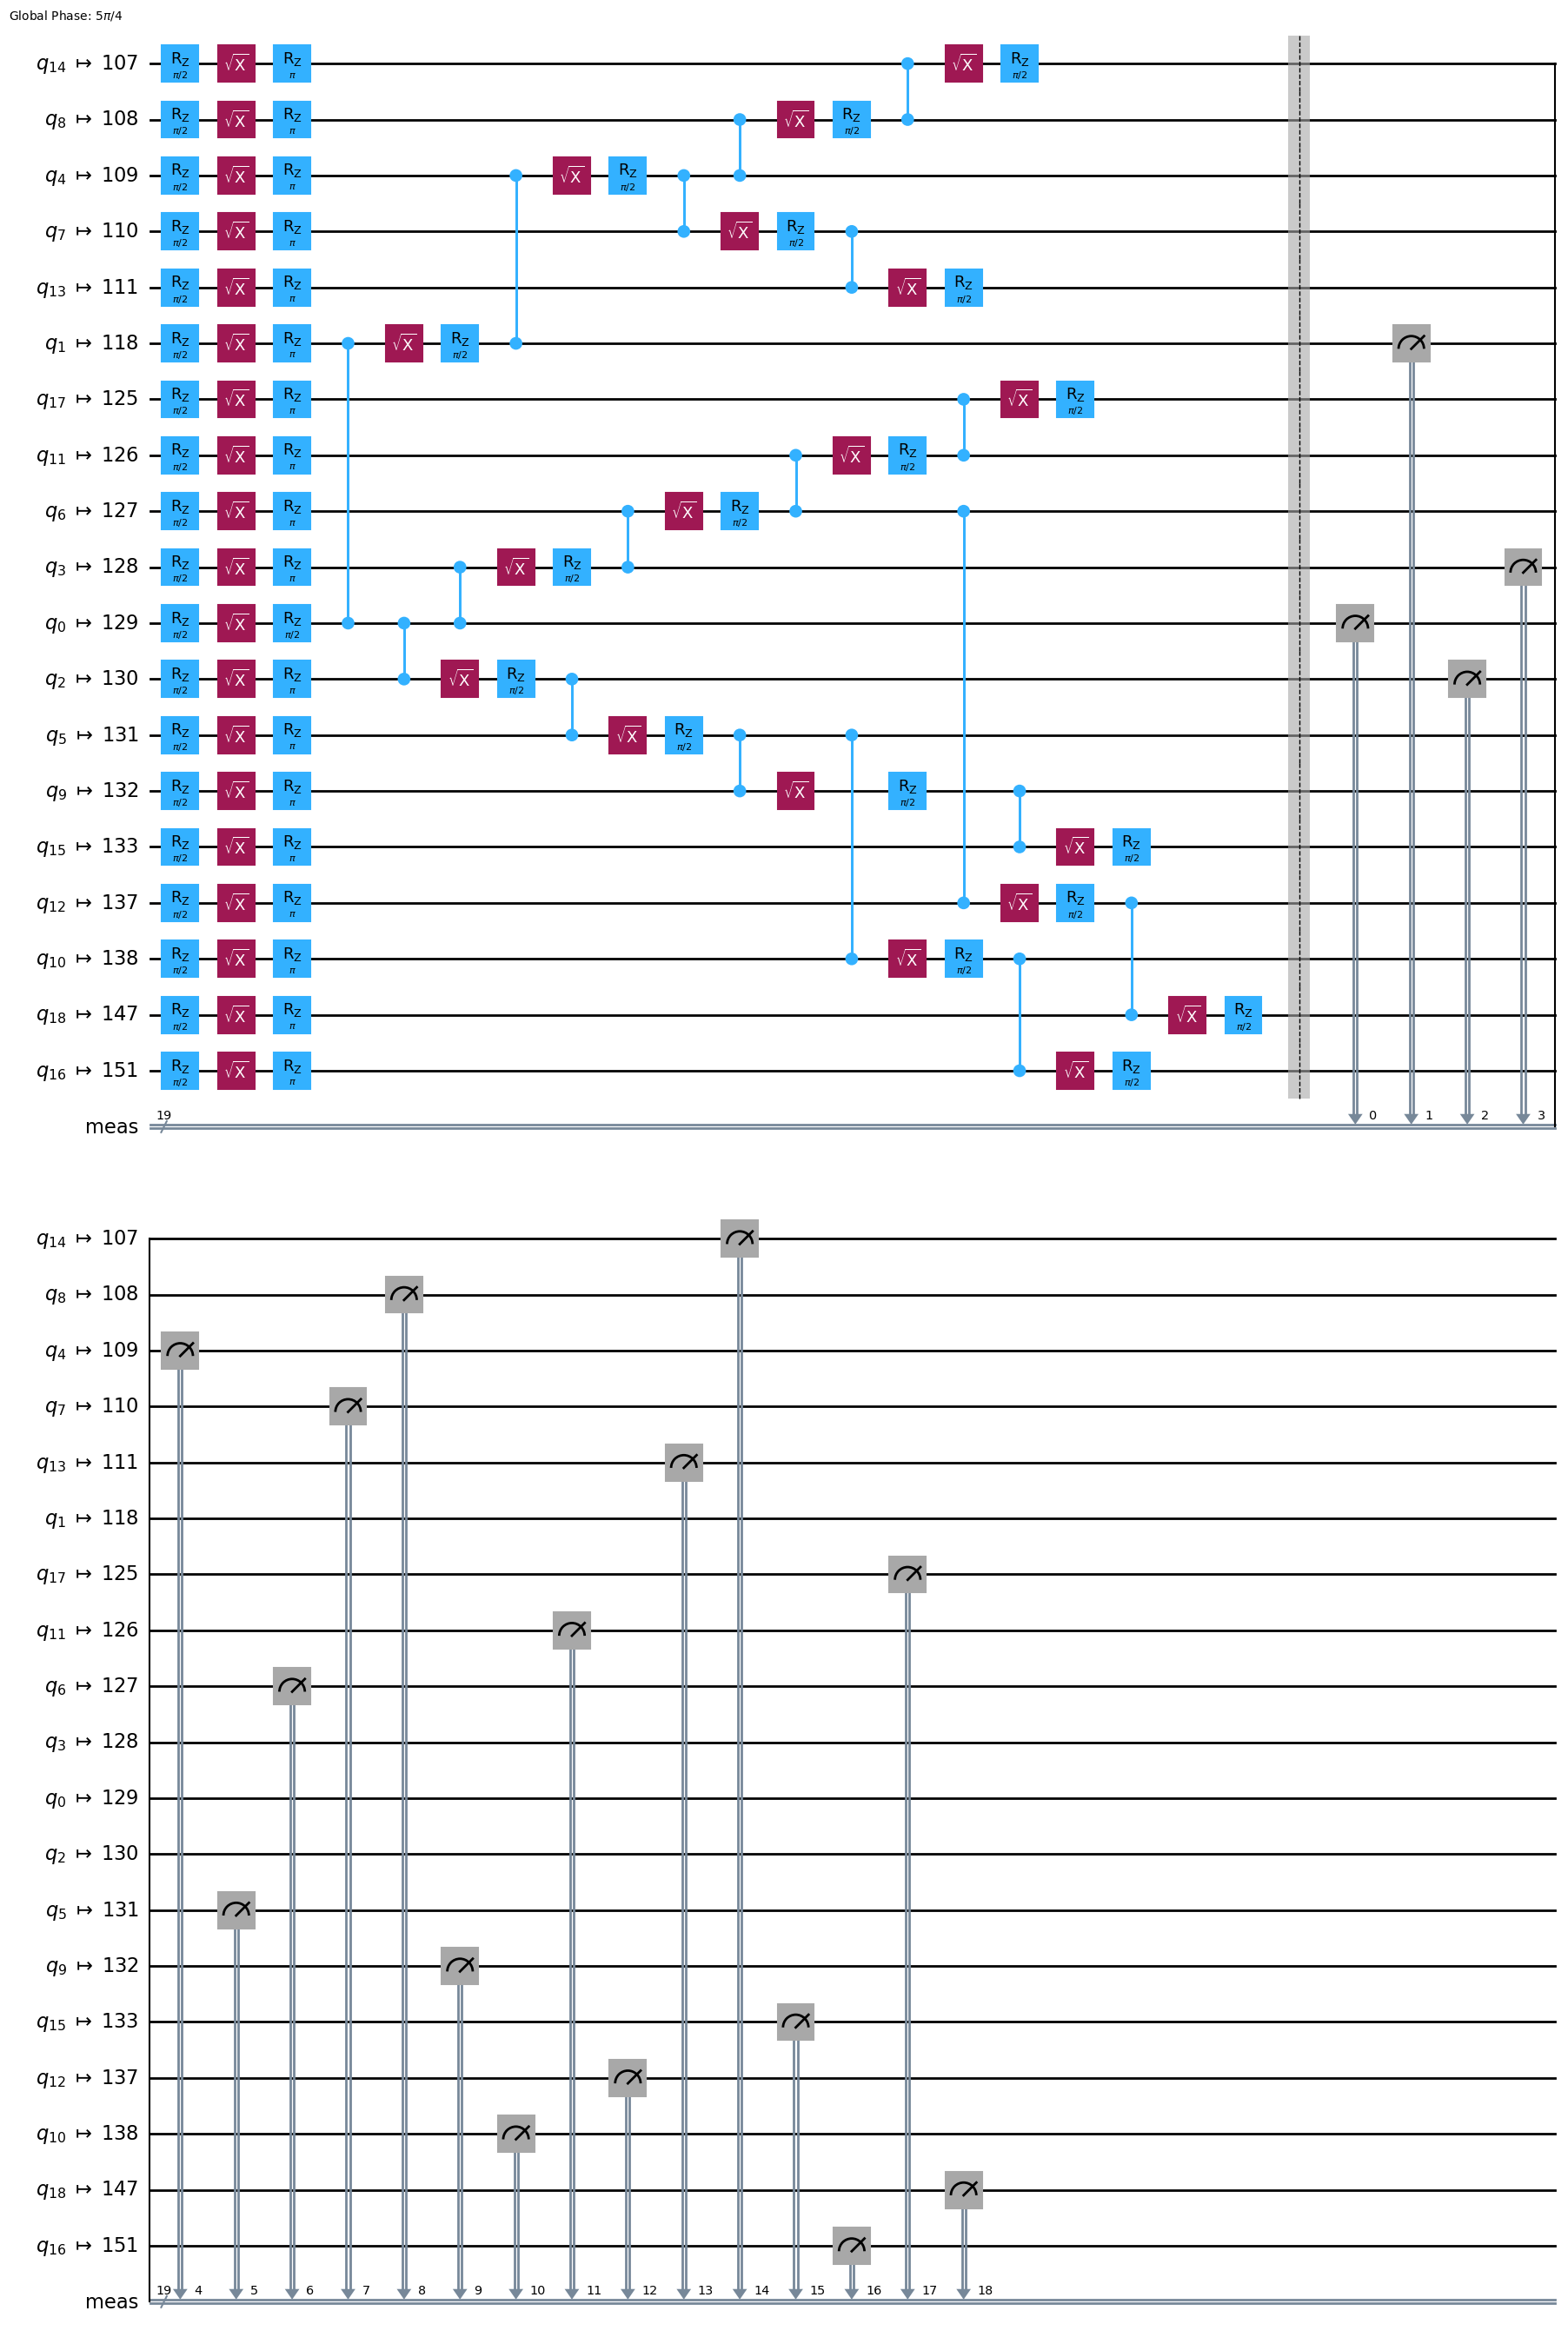

In [20]:
# Use AerSimulator as backend
backend = AerSimulator()
from qiskit_ibm_runtime.fake_provider import FakeFez
backend = FakeFez()
import matplotlib.pyplot as plt

# Generate a pass manager with the instruction set architecture(ISA) and connectivity of the chosen backend
pm = generate_preset_pass_manager(backend=backend)

# Initialize a sampler with the chosen backend
sampler = Sampler(mode=backend)

# Transpile the circuit into the ISA of the chosen backend
isa_circuit = pm.run(qc)
isa_circuit.draw(output='mpl', filename='clever_compiled.pdf')

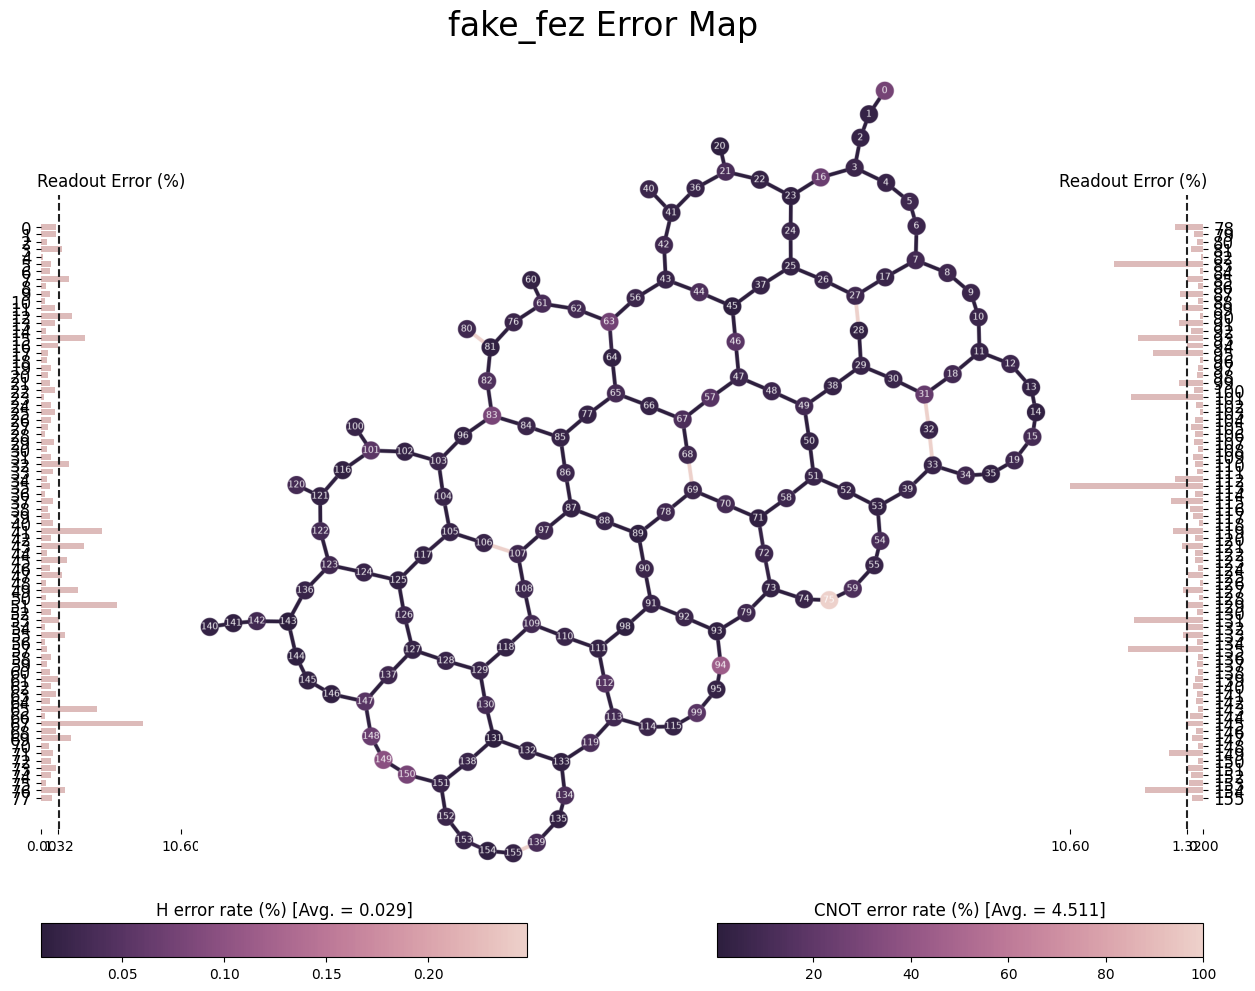

In [5]:
from qiskit.visualization import plot_error_map
fig = plot_error_map(backend)
fig

### 1.3 Run using sampler primitive

In [5]:
# Build Primitive unified block(s) (PUB)
# Here we only have one circuit to execute, such that we only need one PUB.
# The details of PUBs only become relevant once one considers parametrized circuits.
pubs = [isa_circuit]

# Submit a job, with 100 measurements
job = sampler.run(pubs, shots=100)

# Retrieve the result
# We only need the first element as we only submitted one pub
pub_result = job.result()[0]

### 1.4 Visualize result

Let us first get an overview of the obtained $\texttt{pub\_result}$ [SamplerPubResult](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.SamplerPubResult).

In [6]:
print("Data:")
for key, value in pub_result.data.items():
    print(key, value)
print("Metadata:")
for key, value in pub_result.metadata.items():
    print(key, value)

Data:
meas BitArray(<shape=(), num_shots=100, num_bits=3>)
Metadata:
shots 100
circuit_metadata {}


We see that the result for the **meas** ClassicalRegister is a [BitArray](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.BitArray).

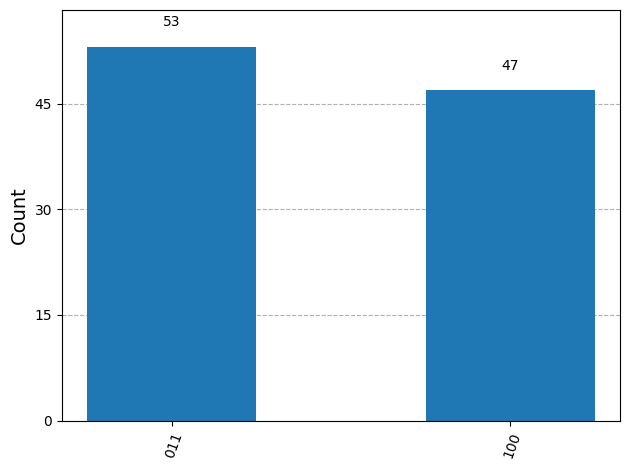

In [7]:
# Retrieve the results for the "meas" ClassicalRegister
meas_result = pub_result.data.meas
meas_result : BitArray # This line is a type hint, which usually improves the autocompletion of IDEs

# Get a dictionary, where the keys are the outcome of the measurement
# and the values are the respective number of times the outcome occurred
counts = meas_result.get_counts()
plot_histogram(counts)

The outcome of the measurement has the convention $q_2q_1q_0$, which is the opposite of the one adopted here (and in the book by Nielsen and Chuang). You can convert the notation to the one used here with:

In [8]:
print(f"Qiskit convention: {counts}")
counts_reordered = {}
for key, value in counts.items():
    counts_reordered[key[::-1]] = value
print(f"N&C convention: {counts_reordered}")

Qiskit convention: {'011': 53, '100': 47}
N&C convention: {'110': 53, '001': 47}


# 2 Custom classical registers

If you only want to measure a subset of all qubits,
or if you want to measure into independent ClassicalRegisters a bit more work is necessary.

### 2.1 Build circuit

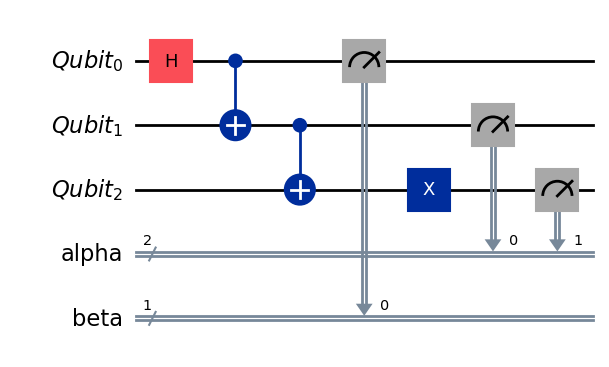

In [9]:
# Initialize QuantumRegister, providing a name
qreg = QuantumRegister(3, "Qubit")

# Initialize ClassicalRegisters, providing names
alpha = ClassicalRegister(2, "alpha")
beta = ClassicalRegister(1, "beta")

# In this case we separately provide a QuantumRegister and ClassicalRegisters
qc = QuantumCircuit(qreg, alpha, beta)

# Build a simple example circuit:
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.x(2)

# Measure the specified qubits into the specified ClassicalRegister
qc.measure([0], beta)
qc.measure([1, 2], alpha)

# If you passed the classical registers, in the order in which they will measure the qubits, into QuantumCircuit(...),
# you can use measure_all, without adding ClassicalRegisters, like this:
# qc.measure_all(add_bits=False)

# If you do not want to specify a name in case of one ClassicalRegister, you can proceed as follows:
# qc = QuantumCircuit(3, 2) # 3 Qubits, 2 classical bits
# ...build circuit...
# qc.measure([1, 2], [0,1]) # Measure qubit 1 into bit 0 and qubit 2 into bit 1
# Note, that this way qiskit will choose a default name for the ClassicalRegister,
#       which you will need in order to retrieve the results.

# Visualize the circuit:
qc.draw(output='mpl')

**Note** that the provided names are shown in the respective registers.

### 2.2 Transpile circuit and run using sampler primitive (as above)

In [10]:
# Use AerSimulator as backend
backend = AerSimulator()

# Generate a pass manager with the instruction set architecture(ISA) and connectivity of the chosen backend
pm = generate_preset_pass_manager(backend=backend)

# Initialize a sampler with the chosen backend
sampler = Sampler(mode=backend)

# Transpile the circuit into the ISA of the chosen backend
isa_circuit = pm.run(qc)

# Build Primitive unified block(s) (PUB)
# Here we only have one circuit to execute, such that we only need one PUB.
# The details of PUBs only become relevant once one considers parametrized circuits.
pubs = [isa_circuit]

# Submit a job, with 100 measurements
job = sampler.run(pubs, shots=100)

# Retrieve the result
# We only need the first element as we only submitted one pub
pub_result = job.result()[0]

### 2.3 Visualize result

Let us first get an overview of the obtained $\texttt{pub\_result}$ [SamplerPubResult](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.SamplerPubResult).

In [11]:
print("Data:")
for key, value in pub_result.data.items():
    print(key, value)
print("Metadata:")
for key, value in pub_result.metadata.items():
    print(key, value)

Data:
alpha BitArray(<shape=(), num_shots=100, num_bits=2>)
beta BitArray(<shape=(), num_shots=100, num_bits=1>)
Metadata:
shots 100
circuit_metadata {}


We now see that we have results for both ClassicalRegisters in the form of a [BitArray](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.BitArray).

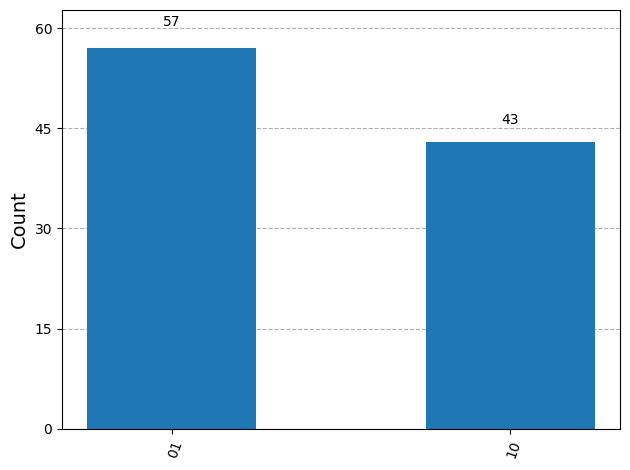

In [12]:
# Retrieve the results for the "alpha" ClassicalRegister
alpha_result = pub_result.data.alpha
alpha_result : BitArray # This line is a type hint, which usually improves the autocompletion of IDEs

# Get a dictionary, where the keys are the outcome of the measurement
# and the values are the respective number of times the outcome occurred
counts = alpha_result.get_counts()
plot_histogram(counts)

### 3 Further reading

There are more methods of [QuantumCircuit](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit), which you might find useful, when building a circuit.